# 04 Baseline Models

This notebook establishes baseline performance for the income prediction task. We evaluate non-informative models (Dummy Classifier), a linear model (Logistic Regression), and a non-linear but interpretable model (Decision Tree).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_auc_score, 
    roc_curve, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score
)

# Setup styling
plt.style.use('ggplot')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.figsize': (10, 6)
})
COLORS = ['#475ED1', '#E3120B']  # Economist blue/red

# Add src to path
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import load_and_split_data, get_preprocessing_pipeline

def save_and_show(fig_name: str):
    """Saves figure to outputs/figures and shows it."""
    out_dir = PROJECT_ROOT / "outputs" / "figures"
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir / f"{fig_name}.png", dpi=300, bbox_inches='tight')
    plt.show()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "adult_cleaned.csv"
print("Setup complete.")

Setup complete.


## 1. Load and Preprocess Data

We use the stratified split and preprocessing pipeline consistent with our experimental design.

In [3]:
# Load data
df_train, df_val, df_test = load_and_split_data(DATA_PATH)

# Separate features and target
target = 'income'
X_train, y_train = df_train.drop(columns=[target]), df_train[target]
X_val, y_val = df_val.drop(columns=[target]), df_val[target]
X_test, y_test = df_test.drop(columns=[target]), df_test[target]

# Encode target: <=50K -> 0, >50K -> 1
y_train = (y_train == '>50K').astype(int)
y_val = (y_val == '>50K').astype(int)
y_test = (y_test == '>50K').astype(int)

# Define features for pipeline
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
cat_cols = [c for c in X_train.columns if c not in num_cols]

# Get pipeline (scale=True for Logistic Regression)
preprocessor = get_preprocessing_pipeline(num_cols, cat_cols, scale=True)

# Fit on TRAIN, transform others
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print(f"Preprocessed Train shape: {X_train_proc.shape}")

Preprocessed Train shape: (39073, 67)


## 2. Model Evaluation Framework

We define a helper function to collect and report all required metrics consistently.

In [4]:
results_list = []

def evaluate_model(model, X, y, name):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else None
    
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision (>50K)': precision_score(y, y_pred),
        'Recall (>50K)': recall_score(y, y_pred),
        'F1 (>50K)': f1_score(y, y_pred),
        'ROC AUC': roc_auc_score(y, y_proba) if y_proba is not None else np.nan
    }
    results_list.append(metrics)
    
    print(f"--- {name} Evaluation ---")
    print(classification_report(y, y_pred))
    if y_proba is not None:
        print(f"ROC AUC: {metrics['ROC AUC']:.4f}")
    
    return y_pred, y_proba

print("Helper Initiated")

Helper Initiated


## 3. Baselines: Dummy Classifier

Non-informative baselines help establish a performance floor.

In [5]:
# Most Frequent Baseline
dummy_mf = DummyClassifier(strategy='most_frequent')
dummy_mf.fit(X_train_proc, y_train)
evaluate_model(dummy_mf, X_val_proc, y_val, "Dummy (Most Frequent)")

# Stratified Baseline
dummy_strat = DummyClassifier(strategy='stratified', random_state=42)
dummy_strat.fit(X_train_proc, y_train)
evaluate_model(dummy_strat, X_val_proc, y_val, "Dummy (Stratified)")

pd.DataFrame(results_list)

--- Dummy (Most Frequent) Evaluation ---
              precision    recall  f1-score   support

           0       0.76      1.00      0.86      3715
           1       0.00      0.00      0.00      1169

    accuracy                           0.76      4884
   macro avg       0.38      0.50      0.43      4884
weighted avg       0.58      0.76      0.66      4884

ROC AUC: 0.5000


/Users/benmearz/PROJECTS/predictive_income_project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/benmearz/PROJECTS/predictive_income_project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/benmearz/PROJECTS/predictive_income_project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control

--- Dummy (Stratified) Evaluation ---
              precision    recall  f1-score   support

           0       0.76      0.76      0.76      3715
           1       0.24      0.24      0.24      1169

    accuracy                           0.64      4884
   macro avg       0.50      0.50      0.50      4884
weighted avg       0.64      0.64      0.64      4884

ROC AUC: 0.5017


,Model,Accuracy,Precision (>50K),Recall (>50K),F1 (>50K),ROC AUC
0,Dummy (Most Frequent),0.760647,0.000000,0.000000,0.000000,0.500000
1,Dummy (Stratified),0.638411,0.242005,0.239521,0.240757,0.501725


### Model Card: Dummy Classifier
- **Objective:** Establish a performance floor by predicting based on label distribution.
- **Hyperparameters:** `strategy='most_frequent'` and `strategy='stratified'`.
- **Interpretation:** The 'Most Frequent' strategy achieves ~76% accuracy but zero recall for the minority class (>50K). This confirms that accuracy is a misleading metric for this imbalanced dataset.

## 4. Logistic Regression

A standard linear baseline using L2 regularization.

In [6]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_proc, y_train)
lr_preds, lr_proba = evaluate_model(lr_model, X_val_proc, y_val, "Logistic Regression")

--- Logistic Regression Evaluation ---
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      3715
           1       0.72      0.59      0.64      1169

    accuracy                           0.85      4884
   macro avg       0.80      0.76      0.77      4884
weighted avg       0.84      0.85      0.84      4884

ROC AUC: 0.9030


In [7]:
# Train performance
train_probs = lr_model.predict_proba(X_train_proc)[:, 1]
val_probs = lr_model.predict_proba(X_val_proc)[:, 1]

print("Logistic Regression AUC")
print("Train AUC:", roc_auc_score(y_train, train_probs))
print("Val AUC:  ", roc_auc_score(y_val, val_probs))

Logistic Regression AUC
Train AUC: 0.9014151033088398
Val AUC:   0.9030028771528277


### Model Card: Logistic Regression
- **Objective:** Minimize log-loss using a linear combination of features.
- **Key Hyperparameters:** `C=1.0` (default), `penalty='l2'`.
- **Overfitting Control:** L2 regularization is applied by default (`C=1.0`).
- **Interpretation:** Logistic regression provides a significantly better balance between precision and recall than the dummy baselines, indicating that the features have linear predictive power.

## 5. Decision Tree (Overfitting Control)

We use a grid search to find optimal depth and leaf constraints to ensure the model generalizes well.

In [8]:
dt_param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 20, 50]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_proc, y_train)
best_dt = grid_search.best_estimator_

print(f"Best Params: {grid_search.best_params_}")
dt_preds, dt_proba = evaluate_model(best_dt, X_val_proc, y_val, "Decision Tree (Tuned)")

Best Params: {'max_depth': None, 'min_samples_leaf': 50}
--- Decision Tree (Tuned) Evaluation ---
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      3715
           1       0.76      0.63      0.69      1169

    accuracy                           0.86      4884
   macro avg       0.83      0.78      0.80      4884
weighted avg       0.86      0.86      0.86      4884

ROC AUC: 0.9112


In [9]:
train_probs_tree = best_dt.predict_proba(X_train_proc)[:, 1]
val_probs_tree = best_dt.predict_proba(X_val_proc)[:, 1]

print("Decision Tree AUC")
print("Train AUC:", roc_auc_score(y_train, train_probs_tree))
print("Val AUC:  ", roc_auc_score(y_val, val_probs_tree))

Decision Tree AUC
Train AUC: 0.9246545362843922
Val AUC:   0.9112444981216187


### Overfitting Control in Decision Trees
- **Max Depth:** Limits the complexity of the tree. Shallow trees are less likely to capture noise (low variance) but might underfit (high bias).
- **Min Samples Leaf:** Ensures each terminal node represents a sufficient number of observations, preventing the tree from isolating outliers or small patterns that don't generalize.

### Model Card: Decision Tree
- **Objective:** Minimize Gini impurity by recursively splitting the data.
- **Key Hyperparameters:** `max_depth`, `min_samples_leaf` (optimized via grid search).
- **Overfitting Control:** Pre-pruning via depth and leaf constraints.
- **Interpretation:** The tuned decision tree offers performance comparable to logistic regression while providing clear, rule-based logic for predictions.

### Top Features ###

Displaying the 15 most important features for the decision tree model.

In [10]:
# Extract feature names manually from fitted ColumnTransformer
feature_names = []
for name, transformer, cols in preprocessor.transformers_:
    if name != 'remainder':
        if hasattr(transformer, 'named_steps'):
            # If pipeline, get last step
            last_step = list(transformer.named_steps.values())[-1]
            if hasattr(last_step, 'get_feature_names_out'):
                try:
                    names = last_step.get_feature_names_out(cols)
                except:
                    names = cols
            else:
                names = cols
        else:
            names = cols
        feature_names.extend(names)

feature_names = np.array(feature_names)

importances = best_dt.feature_importances_

print(len(feature_names), len(importances))

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_imp.head(15))

67 67
                              feature  importance
32  marital-status_Married-civ-spouse    0.394588
3                       education-num    0.211149
0                        capital-gain    0.181528
2                                 age    0.054812
1                        capital-loss    0.054414
4                      hours-per-week    0.037530
40         occupation_Exec-managerial    0.012049
25                  education_HS-grad    0.008142
10         workclass_Self-emp-not-inc    0.006915
23                education_Bachelors    0.006312
46          occupation_Prof-specialty    0.003811
57                  relationship_Wife    0.003730
44           occupation_Other-service    0.003105
41         occupation_Farming-fishing    0.002431
64                           sex_Male    0.002419


## 6. Model Comparison

We compare the models using ROC curves and confusion matrices.

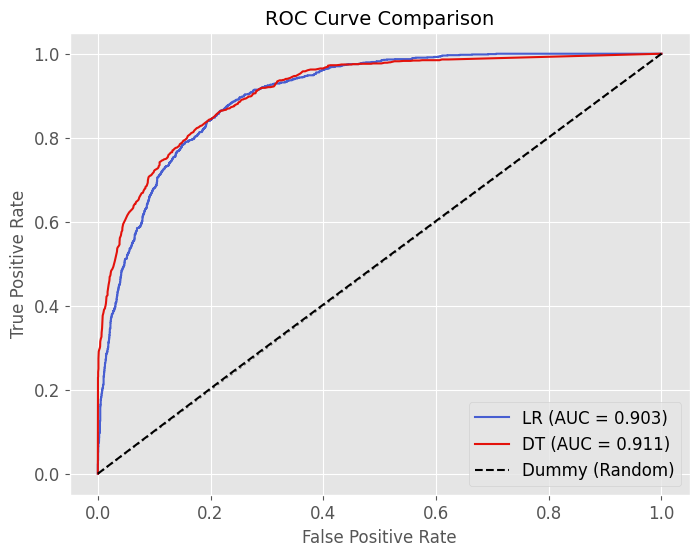

In [11]:
# Plot ROC Curves
plt.figure(figsize=(8, 6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_val, lr_proba)
plt.plot(fpr_lr, tpr_lr, label=f'LR (AUC = {roc_auc_score(y_val, lr_proba):.3f})', color=COLORS[0])

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_val, dt_proba)
plt.plot(fpr_dt, tpr_dt, label=f'DT (AUC = {roc_auc_score(y_val, dt_proba):.3f})', color=COLORS[1])

# Dummy (Stratified) - only if it has proba
dummy_proba = dummy_strat.predict_proba(X_val_proc)[:, 1]
fpr_ds, tpr_ds, _ = roc_curve(y_val, dummy_proba)
plt.plot(fpr_ds, tpr_ds, 'k--', label='Dummy (Random)')

plt.plot([0, 1], [0, 1], 'k:', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
save_and_show('baselines_roc_comparison')

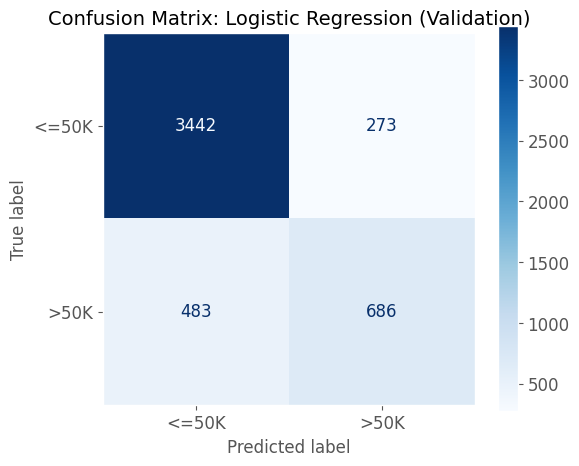

In [12]:
# Confusion Matrix for the best model (Logistic Regression often slightly better or similar to best DT)
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, lr_preds, 
    display_labels=['<=50K', '>50K'],
    cmap='Blues', 
    values_format='d', 
    ax=ax
)
plt.title('Confusion Matrix: Logistic Regression (Validation)')
plt.grid(False)
save_and_show('baselines_confusion_matrix_logistic_regression')

In [13]:
# Summary Table
results_df = pd.DataFrame(results_list).sort_values('F1 (>50K)', ascending=False)
results_df

,Model,Accuracy,Precision (>50K),Recall (>50K),F1 (>50K),ROC AUC
3,Decision Tree (Tuned),0.864865,0.763731,0.630453,0.690722,0.911244
2,Logistic Regression,0.845209,0.715328,0.586826,0.644737,0.903003
1,Dummy (Stratified),0.638411,0.242005,0.239521,0.240757,0.501725
0,Dummy (Most Frequent),0.760647,0.000000,0.000000,0.000000,0.500000
